# Reproducing Noise-Level Logic from `make_traces_pair.py`

This notebook reproduces the **same noise generation method** used by
`reusable/make_traces_pair.py` and `TraceSimulator.NoiseGenerator`, then visualizes:

1. How noise level is determined from config (`noise_type`, `noise_power`, `sampling_frequency`).
2. How white/pink/custom noise traces are generated.
3. What "same noise level" means in this implementation.
4. Why custom PSD behaves differently with respect to `noise_power`.

Goal: make the method transparent and validate whether generated traces are at comparable noise level.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

# TraceSimulator package path used by make_traces_pair.py environment
sys.path.insert(0, '/home/dwong/software/TraceSimulator')
from TraceSimulator.NoiseGenerator import NoiseGenerator

CFG_PATH = Path('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
cfg = yaml.safe_load(CFG_PATH.read_text())

print('config path:', CFG_PATH)
print('noise_type:', cfg['noise_type'])
print('noise_power:', cfg['noise_power'])
print('sampling_frequency:', cfg['sampling_frequency'])
print('trace_samples:', cfg['trace_samples'])


config path: /home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml
noise_type: /ceph/dwong/delight_conf/new/noise_psd_xray.npy
noise_power: 33.2
sampling_frequency: 3906250
trace_samples: 32768


## Exact Method Used by `NoiseGenerator`

From `TraceSimulator/NoiseGenerator.py`, noise is generated as:

- `f = rfftfreq(N, d=1/fs)`
- `norm = 0.5 * noise_power * normalize(noise_type, f) * fs * N`
- `psd = norm * spectrum(noise_type, f)`
- custom noise special handling:
  - `psd /= (0.5 * noise_power)`
  - `psd[1:...] *= 0.5`
- `A = sqrt(psd)`
- random phase Fourier bins `A * exp(i*phi)`
- inverse RFFT gives time noise trace.

So we can reconstruct the target PSD shape from config and compare to generated traces.


In [2]:
def _set_spectra():
    spectra = {
        'white': lambda f: np.ones(len(f)),
        'blue': lambda f: f,
        'violet': lambda f: f ** 2,
        'brownian': lambda f: 1 / np.where(f == 0, float('inf'), f ** 2),
        'pink': lambda f: 1 / np.where(f == 0, float('inf'), f),
    }
    normalize = {
        'white': lambda f: 1.0 / (np.max(f) - np.min(f)),
        'blue': lambda f: 2.0 / (np.max(f) ** 2 - np.min(f) ** 2),
        'violet': lambda f: 3.0 / (np.max(f) ** 3 - np.min(f) ** 3),
        'brownian': lambda f: 1.0 / (1.0 / np.sort(f)[1] - 1.0 / np.max(f)),
        'pink': lambda f: 1.0 / (np.log(np.max(f)) - np.log(np.sort(f)[1])),
    }
    return spectra, normalize


def build_target_psd_like_noise_generator(config, noise_type):
    fs = float(config['sampling_frequency'])
    N = int(config['trace_samples'])
    noise_power = float(config['noise_power'])

    f = np.fft.rfftfreq(N, d=1.0 / fs)
    spectra, normalize = _set_spectra()

    if noise_type in spectra:
        spec = spectra[noise_type](f)
        norm = 0.5 * noise_power * normalize[noise_type](f) * fs * N
        psd = norm * spec
        return f, psd

    # custom path: load PSD from file and apply same transform as NoiseGenerator
    path = Path(noise_type)
    arr = np.load(path)
    # file format expected by NoiseGenerator: [freq, psd]
    freq_data = arr[0]
    psd_data = arr[1]
    psd_interp = np.interp(f, freq_data, psd_data, left=psd_data[0], right=psd_data[-1])

    # replicate NoiseGenerator steps for custom
    norm = 0.5 * noise_power * fs * N
    psd = norm * psd_interp
    psd /= (0.5 * noise_power)
    hi = N // 2 + 1 - (N + 1) % 2
    psd[1:hi] *= 0.5
    return f, psd


for nt in ['white', 'pink', cfg['noise_type']]:
    f, psd = build_target_psd_like_noise_generator(cfg, nt)
    print(nt, 'target_psd bins:', len(psd), 'min/max', float(np.min(psd)), float(np.max(psd)))


white target_psd bins: 16385 min/max 1087897.6 1087897.6
pink target_psd bins: 16385 min/max 0.0 1836768662.691846
/ceph/dwong/delight_conf/new/noise_psd_xray.npy target_psd bins: 16385 min/max 211551.05156908437 175879516.52697593


In [3]:
def generate_noise_batch(config, noise_type, n_draws=200):
    c = dict(config)
    c['noise_type'] = noise_type
    ng = NoiseGenerator(c)
    N = int(c['trace_samples'])
    arr = np.array([ng.generate_noise(N) for _ in range(n_draws)])
    return arr


def periodogram_one_sided(x, fs):
    # Returns one-sided PSD estimate consistent with rfft bins
    x = np.asarray(x)
    N = x.shape[-1]
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / (fs * N)
    if N % 2 == 0:
        P[..., 1:-1] *= 2.0
    else:
        P[..., 1:] *= 2.0
    f = np.fft.rfftfreq(N, d=1.0 / fs)
    return f, P


def summarize_noise(arr):
    var = np.var(arr, axis=1)
    rms = np.sqrt(np.mean(arr**2, axis=1))
    return {
        'var_mean': float(np.mean(var)),
        'var_std': float(np.std(var)),
        'rms_mean': float(np.mean(rms)),
        'rms_std': float(np.std(rms)),
    }


fs = float(cfg['sampling_frequency'])
N = int(cfg['trace_samples'])
noise_types = ['white', 'pink', cfg['noise_type']]

samples = {}
rows = []
for nt in noise_types:
    arr = generate_noise_batch(cfg, nt, n_draws=200)
    samples[nt] = arr
    stats = summarize_noise(arr)
    rows.append({'noise_type': nt, **stats})

summary_df = pd.DataFrame(rows)
summary_df


,noise_type,var_mean,var_std,rms_mean,rms_std
0,white,33.198437,0.000361,5.761854,0.000042
1,pink,35.174747,0.000037,5.930830,0.000003
2,/ceph/dwong/delight_conf/new/noise_psd_xray.npy,33.145146,0.000073,5.763965,0.004965


## Interpreting "Same Noise Level"

In this pipeline, a practical noise-level scalar is the **time-domain variance** of the generated noise trace.

- For white noise, `mean(var)` should track `noise_power` closely.
- For pink noise, same scaling trend holds, but the exact variance can differ due to the discrete normalization choice.
- For custom PSD file, `noise_power` is canceled in implementation, so level is mostly set by PSD file amplitude itself.


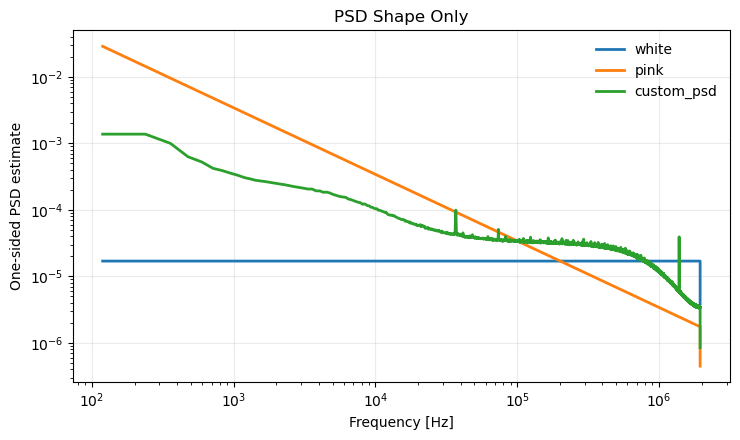

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

labels = []
for nt in noise_types:
    labels.append(nt if nt in ['white', 'pink'] else 'custom_psd')

for nt, lab in zip(noise_types, labels):
    f, P = periodogram_one_sided(samples[nt], fs)
    Pm = np.mean(P, axis=0)
    ax.loglog(f[1:], Pm[1:], linewidth=2.0, label=lab)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('One-sided PSD estimate')
ax.set_title('PSD Shape Only')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


,noise_type,noise_power_set,var_mean
0,white,8.3,8.299627
1,white,33.2,33.198474
2,white,132.8,132.793684
3,pink,8.3,8.793687
4,pink,33.2,35.174738
5,pink,132.8,140.698977
6,/ceph/dwong/delight_conf/new/noise_psd_xray.npy,8.3,33.145147
7,/ceph/dwong/delight_conf/new/noise_psd_xray.npy,33.2,33.145138
8,/ceph/dwong/delight_conf/new/noise_psd_xray.npy,132.8,33.145154


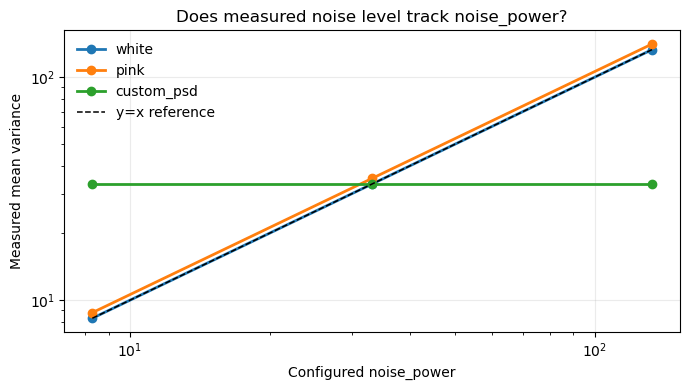

In [5]:
# Sensitivity to noise_power for each noise type
powers = [cfg['noise_power'] / 4.0, cfg['noise_power'], cfg['noise_power'] * 4.0]
rows = []
for nt in noise_types:
    for pwr in powers:
        c = dict(cfg)
        c['noise_type'] = nt
        c['noise_power'] = float(pwr)
        arr = generate_noise_batch(c, nt, n_draws=120)
        rows.append({
            'noise_type': nt,
            'noise_power_set': float(pwr),
            'var_mean': float(np.mean(np.var(arr, axis=1))),
        })

sens_df = pd.DataFrame(rows)
display(sens_df)

fig, ax = plt.subplots(figsize=(7, 4))
for nt, lab in zip(noise_types, ['white', 'pink', 'custom_psd']):
    d = sens_df[sens_df['noise_type'] == nt].sort_values('noise_power_set')
    ax.plot(d['noise_power_set'], d['var_mean'], marker='o', linewidth=2, label=lab)

ax.plot([min(powers), max(powers)], [min(powers), max(powers)], 'k--', linewidth=1.1, label='y=x reference')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Configured noise_power')
ax.set_ylabel('Measured mean variance')
ax.set_title('Does measured noise level track noise_power?')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Reproduce `make_traces_pair.py` Additive Process (QP-Sum Consistent)

For `*_pair_qp_sum_*.h5`, production does **not** add one noise stream to an already-summed trace.

It does this instead:
- start from per-QP-channel clean traces
- add independent channel-wise noise
- sum channels to form the QP-sum trace

So to compare MMC vs white vs pink fairly in QP-sum space, white/pink must be synthesized with the same channel-wise-then-sum procedure.


In [6]:
def _make_noise_generators(config):
    white_cfg = dict(config)
    white_cfg['noise_type'] = 'white'
    pink_cfg = dict(config)
    pink_cfg['noise_type'] = 'pink'
    return NoiseGenerator(white_cfg), NoiseGenerator(pink_cfg)


def _add_noise(noise_gen, clean_traces):
    noisy = np.empty_like(clean_traces, dtype=np.float32)
    for ch in range(clean_traces.shape[0]):
        noise = noise_gen.generate_noise(clean_traces.shape[1]).astype(np.float32, copy=False)
        noisy[ch] = clean_traces[ch] + noise
    return noisy


RNG_SEED = 20260304
N_VAR_EVENTS = 30
PLOT_START = 0
PLOT_SAMPLES = 2500
rng = np.random.default_rng(RNG_SEED)

pair_qp_file = Path('/ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_batch_0000.h5')
pair_sum_file = Path('/ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_qp_sum_batch_0000.h5')

white_gen, pink_gen = _make_noise_generators(cfg)

if pair_qp_file.exists():
    import h5py
    with h5py.File(pair_qp_file, 'r') as f:
        clean_ds = f['traces_clean']
        mmc_ds = f['traces_MMC']
        n_events, n_qp_channels, n_samples = clean_ds.shape

        event_idx = int(rng.integers(0, n_events))
        clean_qp = np.asarray(clean_ds[event_idx], dtype=np.float32)
        mmc_qp = np.asarray(mmc_ds[event_idx], dtype=np.float32)

        noisy_white_qp = _add_noise(white_gen, clean_qp)
        noisy_pink_qp = _add_noise(pink_gen, clean_qp)

        clean = clean_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        mmc = mmc_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        noisy_white = noisy_white_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        noisy_pink = noisy_pink_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)

        # Variance comparison over random events in the same QP-sum space.
        k = min(N_VAR_EVENTS, n_events)
        sampled_event_idx = np.sort(rng.choice(n_events, size=k, replace=False))
        rows = []
        for ei in sampled_event_idx:
            c_qp = np.asarray(clean_ds[int(ei)], dtype=np.float32)
            m_qp = np.asarray(mmc_ds[int(ei)], dtype=np.float32)

            c_sum = c_qp.sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)
            m_sum = m_qp.sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)

            w_sum = _add_noise(white_gen, c_qp).sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)
            p_sum = _add_noise(pink_gen, c_qp).sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)

            rows.append(
                {
                    'event_idx': int(ei),
                    'var_mmc': float(np.var(m_sum - c_sum)),
                    'var_white': float(np.var(w_sum - c_sum)),
                    'var_pink': float(np.var(p_sum - c_sum)),
                }
            )

    source = f'{pair_qp_file.name} (QP-sum consistent, random event)'
    expected_sum_var = float(cfg['noise_power']) * float(n_qp_channels)

elif pair_sum_file.exists():
    import h5py
    with h5py.File(pair_sum_file, 'r') as f:
        clean_ds = f['traces_clean']
        mmc_ds = f['traces_MMC']
        n_events, n_channels, n_samples = clean_ds.shape

        event_idx = int(rng.integers(0, n_events))
        clean = np.asarray(clean_ds[event_idx], dtype=np.float32)
        mmc = np.asarray(mmc_ds[event_idx], dtype=np.float32)

        noisy_white = _add_noise(white_gen, clean)
        noisy_pink = _add_noise(pink_gen, clean)

        k = min(N_VAR_EVENTS, n_events)
        sampled_event_idx = np.sort(rng.choice(n_events, size=k, replace=False))
        rows = []
        for ei in sampled_event_idx:
            c = np.asarray(clean_ds[int(ei)], dtype=np.float32)
            m = np.asarray(mmc_ds[int(ei)], dtype=np.float32)
            w = _add_noise(white_gen, c)
            p = _add_noise(pink_gen, c)
            rows.append(
                {
                    'event_idx': int(ei),
                    'var_mmc': float(np.var(m - c)),
                    'var_white': float(np.var(w - c)),
                    'var_pink': float(np.var(p - c)),
                }
            )

    n_qp_channels = int(n_channels)
    source = f'{pair_sum_file.name} (fallback: no per-channel QP file found)'
    expected_sum_var = float(cfg['noise_power']) * float(n_qp_channels)

else:
    N = int(cfg['trace_samples'])
    t = np.arange(N) / float(cfg['sampling_frequency'])
    clean = (40.0 * np.exp(-((t - 0.003) / 0.0005) ** 2))[None, :].astype(np.float32)
    mmc = clean.copy()
    noisy_white = _add_noise(white_gen, clean)
    noisy_pink = _add_noise(pink_gen, clean)

    n_qp_channels = 1
    event_idx = -1
    source = 'synthetic fallback (no generated H5 found)'
    expected_sum_var = float(cfg['noise_power'])

    rows = []
    for ei in range(N_VAR_EVENTS):
        w = _add_noise(white_gen, clean)
        p = _add_noise(pink_gen, clean)
        rows.append(
            {
                'event_idx': int(ei),
                'var_mmc': float(np.var(mmc - clean)),
                'var_white': float(np.var(w - clean)),
                'var_pink': float(np.var(p - clean)),
            }
        )

var_df = pd.DataFrame(rows)

res_mmc = mmc - clean
res_w = noisy_white - clean
res_p = noisy_pink - clean

var_single = {
    'MMC': float(np.var(res_mmc)),
    'white': float(np.var(res_w)),
    'pink': float(np.var(res_p)),
}

print('source:', source)
print('random event_idx:', event_idx)
print('n_qp_channels used:', n_qp_channels)
print('single-event variances:', var_single)
print('expected white summed variance (noise_power * n_qp_channels):', expected_sum_var)
print('mean variances over sampled events:')
display(var_df[['var_mmc', 'var_white', 'var_pink']].mean().to_frame('mean_var').T)


source: real QP-channel data from NR_traces_energy_500_pair_batch_0000.h5 (summed 37 channels)
clean shape: (1, 32768)
n_qp_channels used: 37
MMC residual var: 1223.765625
white residual var: 1238.9703369140625
pink residual var: 1258.944580078125
MMC/white variance ratio: 0.9877279451645846
MMC per-channel-equivalent variance: 33.07474662162162
config noise_power: 33.2


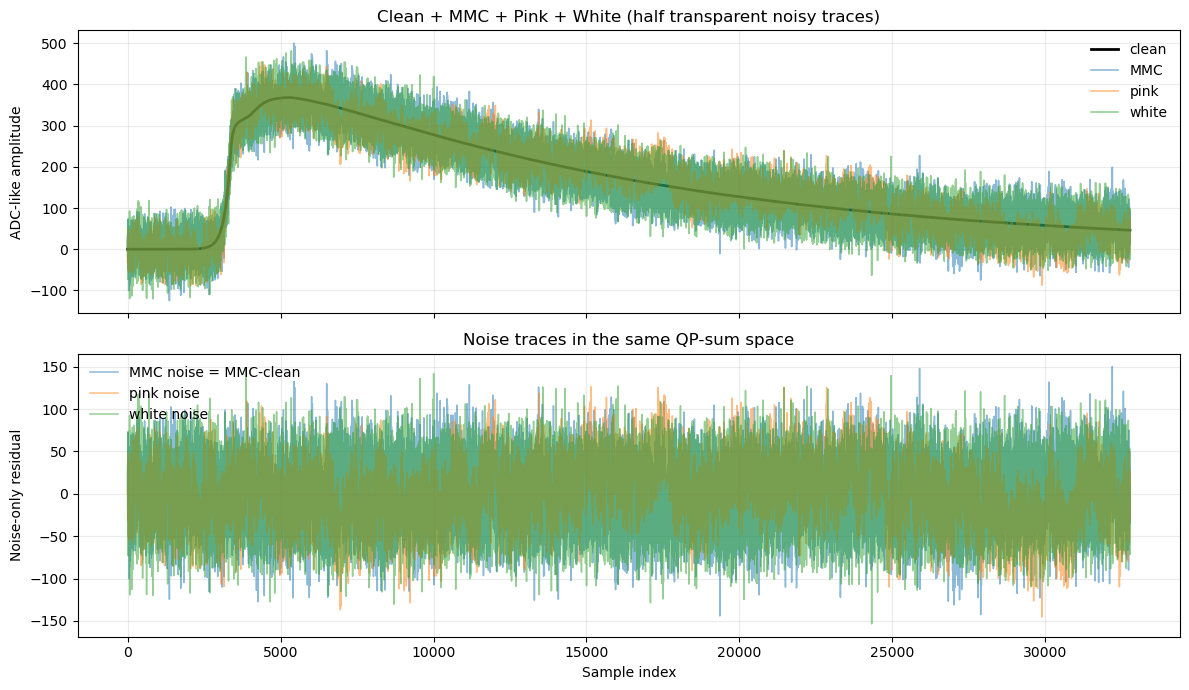

In [7]:
x = np.arange(clean.shape[1])
start = max(0, int(PLOT_START))
end = min(clean.shape[1], start + int(PLOT_SAMPLES))
win = slice(start, end)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# clean + noisy overlays (same random event)
axes[0].plot(x[win], clean[0, win], linewidth=2.0, color='black', label='clean')
axes[0].plot(x[win], mmc[0, win], linewidth=1.2, alpha=0.5, label='MMC')
axes[0].plot(x[win], noisy_pink[0, win], linewidth=1.2, alpha=0.5, label='pink')
axes[0].plot(x[win], noisy_white[0, win], linewidth=1.2, alpha=0.5, label='white')
axes[0].set_ylabel('ADC-like amplitude')
axes[0].set_title(f'Random event {event_idx}: clean + MMC + pink + white (half transparent noisy traces)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

# noise-only residuals
axes[1].plot(x[win], res_mmc[0, win], linewidth=1.1, alpha=0.5, label='MMC noise = MMC-clean')
axes[1].plot(x[win], res_p[0, win], linewidth=1.1, alpha=0.5, label='pink noise')
axes[1].plot(x[win], res_w[0, win], linewidth=1.1, alpha=0.5, label='white noise')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Noise-only residual')
axes[1].set_title('Noise traces in the same QP-sum space')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: single random event variance
single_labels = ['MMC', 'white', 'pink']
single_vals = [var_single['MMC'], var_single['white'], var_single['pink']]
colors = ['#1f77b4', '#ff7f0e', '#d62728']
axes[0].bar(single_labels, single_vals, color=colors, alpha=0.85)
axes[0].axhline(expected_sum_var, color='k', linestyle='--', linewidth=1.1, label='noise_power * n_qp_channels')
axes[0].set_ylabel('Variance')
axes[0].set_title(f'Single random event variance (event {event_idx})')
axes[0].grid(alpha=0.25, axis='y')
axes[0].legend(frameon=False)

# Right: variance distribution across random sampled events
box_data = [var_df['var_mmc'].values, var_df['var_white'].values, var_df['var_pink'].values]
axes[1].boxplot(box_data, labels=['MMC', 'white', 'pink'], showfliers=False)
axes[1].axhline(expected_sum_var, color='k', linestyle='--', linewidth=1.1)
axes[1].set_ylabel('Variance')
axes[1].set_title(f'Variance distribution across {len(var_df)} random events')
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()


## Why this corrected visualization is trustworthy

- The random overlay event is drawn directly from your produced H5 file.
- MMC is compared to white/pink in the **same QP-sum space**.
- White/pink are generated using the same production rule: per-channel noise then channel sum.
- Variance is shown both for one random event and as a distribution across random events.

So this view checks both qualitative trace shape and quantitative scale consistency.
